In [42]:
# Data Manipulation
import numpy as np 
import pandas as pd 

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns 

#NLP
import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.sentiment import SentimentIntensityAnalyzer

# Word Cloud
from wordcloud import WordCloud

# Topic Modeling
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Machine Learning 
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (RandomForestClassifier, RandomForestRegressor)

from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, mean_absolute_error, mean_squared_error, r2_score)

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_excel(r"D:\AnalytixLabs\Data Science & AI\6. Case Studies\Machine Learning Case Studies\5. Capstone Case Study - NLP- Woman Clothing E-Commerce Platform\Womens Clothing Reviews Data.xlsx")

In [4]:
df.head()

,Product ID,Category,Subcategory1,SubCategory2,Location,Channel,Customer Age,Review Title,Review Text,Rating,Recommend Flag
0,767,Initmates,Intimate,Intimates,Mumbai,Mobile,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1
1,1080,General,Dresses,Dresses,Bangalore,Mobile,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1
2,1077,General,Dresses,Dresses,Gurgaon,Mobile,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0
3,1049,General Petite,Bottoms,Pants,Chennai,Web,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1
4,847,General,Tops,Blouses,Bangalore,Web,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Product ID      23486 non-null  int64 
 1   Category        23472 non-null  object
 2   Subcategory1    23472 non-null  object
 3   SubCategory2    23472 non-null  object
 4   Location        23486 non-null  object
 5   Channel         23486 non-null  object
 6   Customer Age    23486 non-null  int64 
 7   Review Title    19676 non-null  object
 8   Review Text     22641 non-null  object
 9   Rating          23486 non-null  int64 
 10  Recommend Flag  23486 non-null  int64 
dtypes: int64(4), object(7)
memory usage: 2.0+ MB


In [16]:
df.isnull().sum()

Product_ID          0
Category            0
Subcategory1        0
SubCategory2        0
Location            0
Channel             0
Customer_Age        0
Review_Title        0
Review_Text       844
Rating              0
Recommend_Flag      0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(3)

In [11]:
df.dropna(subset=['Category', 'Subcategory1', 'SubCategory2'],
          inplace= True)

In [13]:
df.columns = df.columns.str.replace(' ', '_')

In [14]:
df.columns

Index(['Product_ID', 'Category', 'Subcategory1', 'SubCategory2', 'Location',
       'Channel', 'Customer_Age', 'Review_Title', 'Review_Text', 'Rating',
       'Recommend_Flag'],
      dtype='object')

In [15]:
df['Review_Title'] = df['Review_Title'].fillna('')

In [17]:
df.head()

,Product_ID,Category,Subcategory1,SubCategory2,Location,Channel,Customer_Age,Review_Title,Review_Text,Rating,Recommend_Flag
0,767,Initmates,Intimate,Intimates,Mumbai,Mobile,33,,Absolutely wonderful - silky and sexy and comf...,4,1
1,1080,General,Dresses,Dresses,Bangalore,Mobile,34,,Love this dress! it's sooo pretty. i happene...,5,1
2,1077,General,Dresses,Dresses,Gurgaon,Mobile,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0
3,1049,General Petite,Bottoms,Pants,Chennai,Web,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1
4,847,General,Tops,Blouses,Bangalore,Web,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1


In [18]:
df[df['Review_Title'].eq('') & df['Review_Text'].isna()].shape

(843, 11)

In [19]:
df = df[~(df['Review_Title'].eq('') & df['Review_Text'].isna())]

In [20]:
df.shape

(22629, 11)

In [22]:
df.loc[:,'Review_Text'] = df['Review_Text'].fillna('')

In [23]:
df.isnull().sum()

Product_ID        0
Category          0
Subcategory1      0
SubCategory2      0
Location          0
Channel           0
Customer_Age      0
Review_Title      0
Review_Text       0
Rating            0
Recommend_Flag    0
dtype: int64

In [26]:
df['Review'] = (df['Review_Title'] + ' ' + df['Review_Text'])

In [27]:
df.head()

,Product_ID,Category,Subcategory1,SubCategory2,Location,Channel,Customer_Age,Review_Title,Review_Text,Rating,Recommend_Flag,Review
0,767,Initmates,Intimate,Intimates,Mumbai,Mobile,33,,Absolutely wonderful - silky and sexy and comf...,4,1,Absolutely wonderful - silky and sexy and com...
1,1080,General,Dresses,Dresses,Bangalore,Mobile,34,,Love this dress! it's sooo pretty. i happene...,5,1,Love this dress! it's sooo pretty. i happen...
2,1077,General,Dresses,Dresses,Gurgaon,Mobile,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,Some major design flaws I had such high hopes ...
3,1049,General Petite,Bottoms,Pants,Chennai,Web,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,"My favorite buy! I love, love, love this jumps..."
4,847,General,Tops,Blouses,Bangalore,Web,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,Flattering shirt This shirt is very flattering...


In [28]:
# Data Cleaning Done

In [29]:
# Exploratory Data Analysis

<Axes: xlabel='Customer_Age', ylabel='Count'>

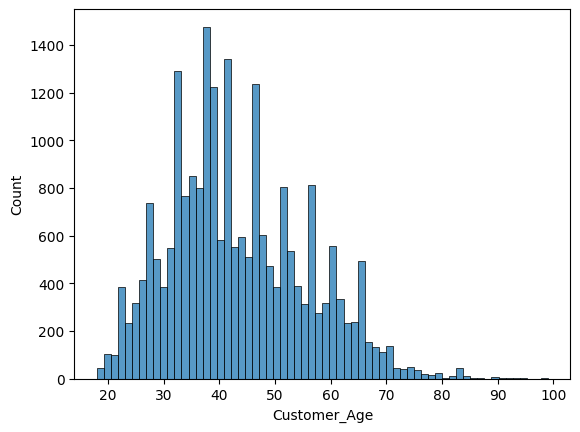

In [31]:
sns.histplot(df['Customer_Age'])

In [32]:
df['Customer_Age'].describe()

count    22629.000000
mean        43.282293
std         12.328220
min         18.000000
25%         34.000000
50%         41.000000
75%         52.000000
max         99.000000
Name: Customer_Age, dtype: float64

In [33]:
print("Mean Age:", df['Customer_Age'].mean())
print("Median Age:", df['Customer_Age'].median())

Mean Age: 43.28229263334659
Median Age: 41.0


<Axes: xlabel='Rating', ylabel='count'>

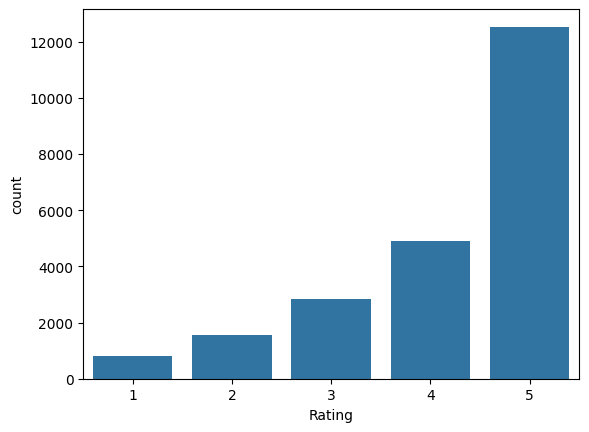

In [34]:
sns.countplot(x='Rating', data=df)

<Axes: xlabel='Recommend_Flag', ylabel='count'>

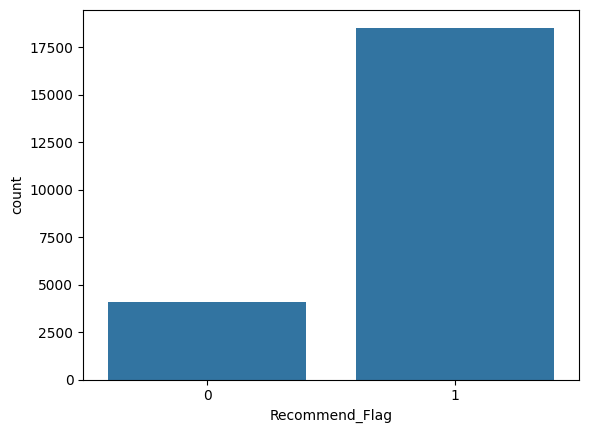

In [35]:
sns.countplot(x='Recommend_Flag', data=df)

<Axes: xlabel='Rating', ylabel='count'>

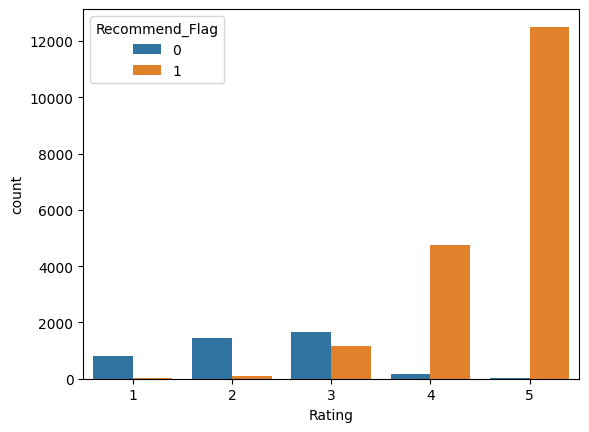

In [36]:
sns.countplot(
    x='Rating',
    hue='Recommend_Flag',
    data=df
)

In [37]:
# Category Analysis

In [47]:
category_rating = df.groupby('Category')['Rating'].mean().sort_values(ascending=False)

In [48]:
category_rating

Category
Initmates         4.275596
General Petite    4.196631
General           4.165345
Name: Rating, dtype: float64

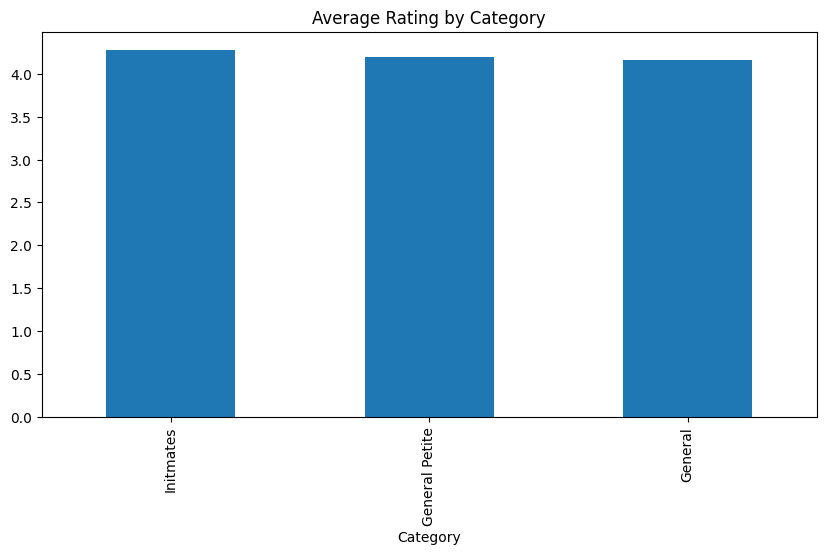

In [49]:
plt.figure(figsize=(10,5))

category_rating.plot(kind='bar')

plt.title('Average Rating by Category')
plt.show()

In [50]:
# Channel Analysis